In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
data = np.load('condensed_data.npy', allow_pickle=True).tolist()

In [79]:
nwindow = 1000
window = np.ones((nwindow,)) / nwindow

experiments = list(data.keys())
print(experiments)
nexp = len(experiments)

methods = ['surrogate_clip','surrogate_noclip', 'standard', 'standard_noclip']

name_map = {
    "surrogate_clip": "surr",
    "surrogate_noclip": "surrogate_noclip",  
    "standard": "stan",
    "standard_noclip": "standard_noclip",
}

['standard_noclip', 'surrogate_noclip', 'surrogate_clip', 'standard']


Energies for surrogate_noclip: [-7.47619247824192, -7.476537139741778, -7.4768589353902355]
Energies for standard_noclip: [-7.477020698484659, -7.477128132481456, -7.477421385412991]


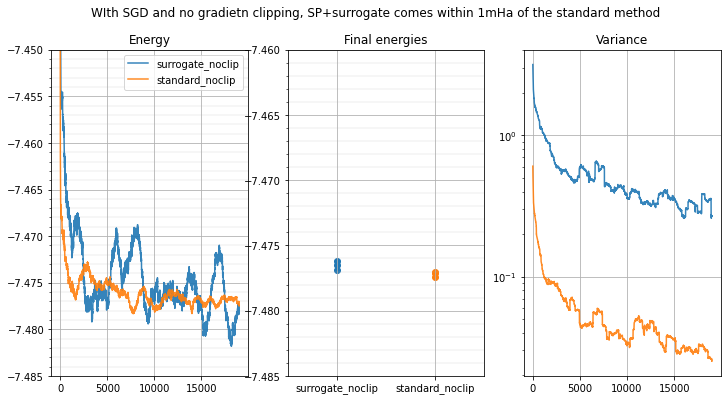

In [82]:
fig, axs = plt.subplots(ncols=3, figsize = (12,6))

fig.suptitle("WIth SGD and no gradietn clipping, SP+surrogate comes within 1mHa of the standard method")

ax = axs[0]
# ax.grid(axis='y')
ax.set_title("Energy")
ax.set_ylim(-7.485, -7.46)
ax.set_yticks(np.linspace(-7.485, -7.45, 8))
ax.set_yticks(np.linspace(-7.485, -7.45, 36), minor=True)
ax.grid(axis='both', which='major')
ax.grid(axis='y', which='minor', linewidth=0.2)


ax = axs[2]
ax.grid()
ax.set_title("Variance")
ax.set_yscale('log')

methods = ['surrogate_noclip', 'standard_noclip']
# methods = ['surrogate_clip','surrogate_noclip', 'standard', 'standard_noclip']
j=1

for m in methods:
    exp = m

    ax = axs[0]
    energies = data[exp][j]['energy_noclip']
    energies_smoothed = np.convolve(energies, window, 'valid')
    ax.plot(energies_smoothed, label=name_map[m], alpha=0.9)
    ax.legend()
       
    ax = axs[2]
    variances = data[exp][j]['variance_noclip']
    variances_smoothed = np.convolve(variances, window, 'valid')
    ax.plot(variances_smoothed, label=name_map[m], alpha=0.9)

ax = axs[1]
# ax.grid(axis='y')
ax.set_title("Final energies")
ax.set_xlim([-0.5,1.5])

ax.set_yticks(np.linspace(-7.485, -7.45, 8))
ax.set_yticks(np.linspace(-7.485, -7.45, 36), minor=True)
ax.grid(axis='both', which='major')
ax.grid(axis='y', which='minor', linewidth=0.2)


ax.set_ylim(-7.485, -7.46)

for m in methods:
    exp = m
    energies = []
    nexp = 3

    for j in range(nexp):
        energies.append(data[exp][j]['eval_stats']['average'])

    print(f"Energies for {exp}: {energies}")

    ax.scatter(nexp*(f"{name_map[m]}",), energies)
    

array([-7.485, -7.484, -7.483, -7.482, -7.481, -7.48 , -7.479, -7.478,
       -7.477, -7.476, -7.475, -7.474, -7.473, -7.472, -7.471, -7.47 ,
       -7.469, -7.468, -7.467, -7.466, -7.465, -7.464, -7.463, -7.462,
       -7.461, -7.46 , -7.459, -7.458, -7.457, -7.456, -7.455, -7.454,
       -7.453, -7.452, -7.451, -7.45 ])

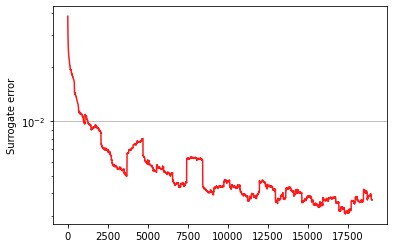

In [27]:
fig, ax = plt.subplots()
nchains = 100

# ax.set_title("Mean squared error of surrogate over training process")
ax.set_yscale('log')
ax.grid(axis='y')
ax.set_ylabel("Surrogate error")

m = 'surrogate_noclip'

exp = m
sg_error = data[exp][j]['sg_error'] / nchains
sg_error_smoothed = np.convolve(sg_error, window, 'valid')
ax.plot(sg_error_smoothed, alpha=0.9, color='r')